# Set Up

In [2]:
%run SetUp.ipynb
%run Process_Data-wModule.ipynb

Home Directory = /home/cjpar/Work/wfe/wfey
Log Path = /home/cjpar/Work/wfe/wfey/logs/logs/
Home Directory = /home/cjpar/Work/wfe/wfey
Log Path = /home/cjpar/Work/wfe/wfey/logs/logs/


## Loading DataFrames

In [3]:
bm_output = pd.read_pickle(HOME_DIRECTORY+'/'+DF+'/'+LOGS+'_output.pkl')
bm_output_raw = pd.read_pickle(HOME_DIRECTORY+'/'+DF+'/'+LOGS+'_output_raw.pkl')

bm_output_clean = pd.read_pickle(HOME_DIRECTORY+'/'+DF+'/'+LOGS+'_output_clean.pkl')
bm_output_clean_raw = pd.read_pickle(HOME_DIRECTORY+'/'+DF+'/'+LOGS+'_output_clean_raw.pkl')

cols = bm_output_clean_raw.columns  ### ?NOTE -- would a different df change the columns - i dont think so

energy_regex = re.compile("energy.*_input")
energy_cols = list(filter(energy_regex.match, cols))

bm_start_index = list(cols).index("epThread")
bm_cols = list(cols[bm_start_index:])

#print("Energy Cols: ", energy_cols)
#print("BM Cols: ", bm_cols)
print("all columns: ", cols)

# Flatten the arrays 
## Time is no longer an element to consider with the module -- but perhaps with more event processors
## this will need to be exploded as well
#bm_energy_output_flat = bm_output.explode(energy_cols +["time"], ignore_index=True)
#bm_energy_output_flat_raw = bm_output_clean_raw.explode(energy_cols +["time"], ignore_index=True)

bm_perf_output_flat = bm_output.explode(bm_cols, ignore_index=True)
bm_perf_output_flat_raw = bm_output_clean_raw.explode(bm_cols, ignore_index=True)

#display(bm_output_raw)
#with pd.option_context('display.max_rows', None, 'display.max_columns', None):
#    print(bm_output_flat_raw)

all columns:  Index(['KEY', 'configs', 'eventrate', 'eventprocCPUs', 'sourceCPUs',
       'latency_min', 'latency_max', 'latency_mean', 'epThread', 'ID', 'Core',
       'Start Energy', 'End Energy', 'Energy Diff', 'Total Wakeups',
       'Spurious Wakeups', 'Events', 'Active Cycles', 'Inactive Cycles',
       'Cycle Diff', 'CPU Cycles', 'Instructions Retired'],
      dtype='object')


## Graph Set-Up

In [4]:
sns.set_palette("Paired")
pd.options.mode.chained_assignment = None
palette_y1 = ["#7209B7"] # purple
palette_y2 = ["#4CC9F0"] # blue


eventsubset=[0, 10, 100, 1000, 100000]
sourceCPUsubset=["1", "10", "50"]

bm_var_energy = "Energy Diff" # in joules
bm_var_to_compare = "latency_mean" # in nanoseconds

def return_df(df):
    print("Event Rate subset: ", eventsubset)
    print("Source CPU subset: ", sourceCPUsubset)
    return df[ (df['eventrate'].isin(eventsubset)) & (df['sourceCPUs'].isin(sourceCPUsubset))].copy()

def return_config_set(df, ecpu, scpu, config):
    return ( df[ (df['eventprocCPUs'] == ecpu) & (df['sourceCPUs'] == scpu) & (df['configs'] == config)] )

df_used = return_df(bm_output)

Event Rate subset:  [0, 10, 100, 1000, 100000]
Source CPU subset:  ['1', '10', '50']


## On Beast

### Busypoll WithOUT Doorbell

##### 1 Event Source, 1 Event Processor

Event Rate subset:  [0, 10, 100, 1000, 100000]
Source CPU subset:  ['1', '10', '50']


<Figure size 640x480 with 0 Axes>

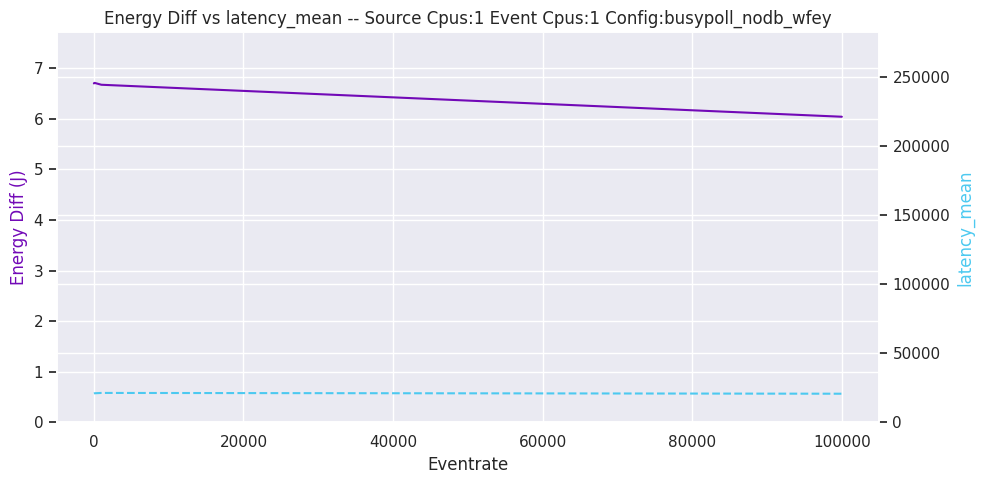

In [5]:
df_used = return_df(bm_perf_output_flat_raw)
config_set = None

num_ecpus = "1"
num_scpus = "1"
cur_config = "busypoll_nodb_wfey"

plt.figure()
config_set = return_config_set(df_used, num_ecpus, num_scpus, cur_config)
#print(config_set)

fig, ax1 = plt.subplots(figsize=(10, 5))

sns.lineplot(
    data=config_set, 
    x='eventrate',
    y=bm_var_energy,
    ax=ax1,
    legend=False,
    hue=ax1,
    palette=palette_y1,
    errorbar=None,
    markers=True,
)
ax2 = ax1.twinx()

sns.lineplot(
    data=config_set, 
    x='eventrate',
    y=bm_var_to_compare,
    ax=ax2,
    legend=False,
    hue=ax1,
    palette=palette_y2,
    errorbar=None,
    linestyle='--',
    markers=True
)


plt.title(bm_var_energy+' vs ' + bm_var_to_compare + ' -- Source Cpus:'+str(num_scpus) +' Event Cpus:'+str(num_ecpus) +' Config:'+str(cur_config) )
ax1.set_xlabel('Eventrate')
ax1.set_ylabel(bm_var_energy + ' (J)', color=palette_y1[0])
ax2.set_ylabel(bm_var_to_compare, color=palette_y2[0])
ax1.set_ylim(0,(df_used[bm_var_energy].max())+1) 
ax2.set_ylim(0,(df_used[bm_var_to_compare].max()))

plt.tight_layout()

##### 10 Event Source, 1 Event Processor

Event Rate subset:  [0, 10, 100, 1000, 100000]
Source CPU subset:  ['1', '10', '50']


<Figure size 640x480 with 0 Axes>

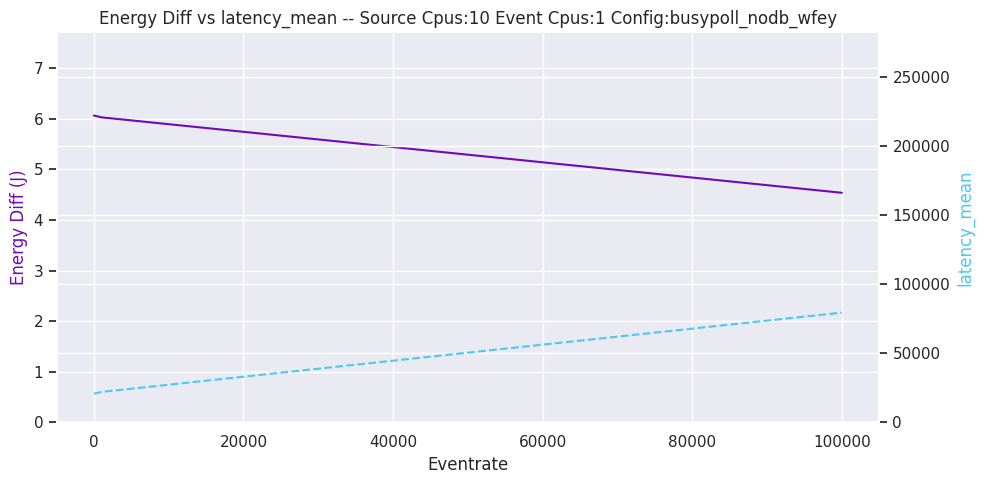

In [6]:
df_used = return_df(bm_perf_output_flat_raw)
config_set = None

num_ecpus = "1"
num_scpus = "10"
cur_config = "busypoll_nodb_wfey"

plt.figure()
config_set = return_config_set(df_used, num_ecpus, num_scpus, cur_config)
#print(config_set)

fig, ax1 = plt.subplots(figsize=(10, 5))

sns.lineplot(
    data=config_set, 
    x='eventrate',
    y=bm_var_energy,
    ax=ax1,
    legend=False,
    hue=ax1,
    palette=palette_y1,
    errorbar=None,
    markers=True,
)
ax2 = ax1.twinx()

sns.lineplot(
    data=config_set, 
    x='eventrate',
    y=bm_var_to_compare,
    ax=ax2,
    legend=False,
    hue=ax1,
    palette=palette_y2,
    errorbar=None,
    linestyle='--',
    markers=True
)


plt.title(bm_var_energy+' vs ' + bm_var_to_compare + ' -- Source Cpus:'+str(num_scpus) +' Event Cpus:'+str(num_ecpus) +' Config:'+str(cur_config) )
ax1.set_xlabel('Eventrate')
ax1.set_ylabel(bm_var_energy + ' (J)', color=palette_y1[0])
ax2.set_ylabel(bm_var_to_compare, color=palette_y2[0])
ax1.set_ylim(0,(df_used[bm_var_energy].max())+1) 
ax2.set_ylim(0,(df_used[bm_var_to_compare].max()))

plt.tight_layout()

##### 50 Event Source, 1 Event Processor

Event Rate subset:  [0, 10, 100, 1000, 100000]
Source CPU subset:  ['1', '10', '50']


<Figure size 640x480 with 0 Axes>

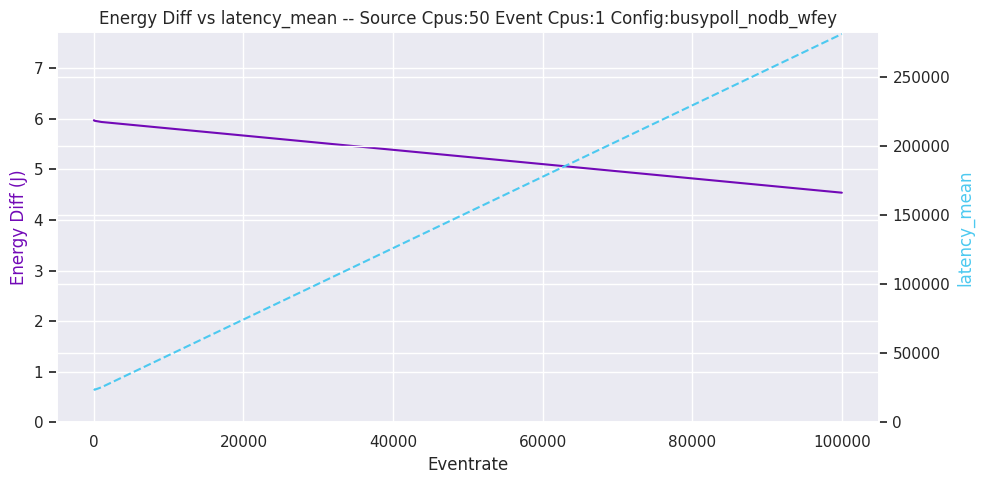

In [7]:
df_used = return_df(bm_perf_output_flat_raw)
config_set = None

num_ecpus = "1"
num_scpus = "50"
cur_config = "busypoll_nodb_wfey"

plt.figure()
config_set = return_config_set(df_used, num_ecpus, num_scpus, cur_config)
#print(config_set)

fig, ax1 = plt.subplots(figsize=(10, 5))

sns.lineplot(
    data=config_set, 
    x='eventrate',
    y=bm_var_energy,
    ax=ax1,
    legend=False,
    hue=ax1,
    palette=palette_y1,
    errorbar=None,
    markers=True,
)
ax2 = ax1.twinx()

sns.lineplot(
    data=config_set, 
    x='eventrate',
    y=bm_var_to_compare,
    ax=ax2,
    legend=False,
    hue=ax1,
    palette=palette_y2,
    errorbar=None,
    linestyle='--',
    markers=True
)


plt.title(bm_var_energy+' vs ' + bm_var_to_compare + ' -- Source Cpus:'+str(num_scpus) +' Event Cpus:'+str(num_ecpus) +' Config:'+str(cur_config) )
ax1.set_xlabel('Eventrate')
ax1.set_ylabel(bm_var_energy + ' (J)', color=palette_y1[0])
ax2.set_ylabel(bm_var_to_compare, color=palette_y2[0])
ax1.set_ylim(0,(df_used[bm_var_energy].max())+1) 
ax2.set_ylim(0,(df_used[bm_var_to_compare].max()))

plt.tight_layout()

### Busypoll With Doorbell

##### 1 Event Source, 1 Event Processor

Event Rate subset:  [0, 10, 100, 1000, 100000]
Source CPU subset:  ['1', '10', '50']


<Figure size 640x480 with 0 Axes>

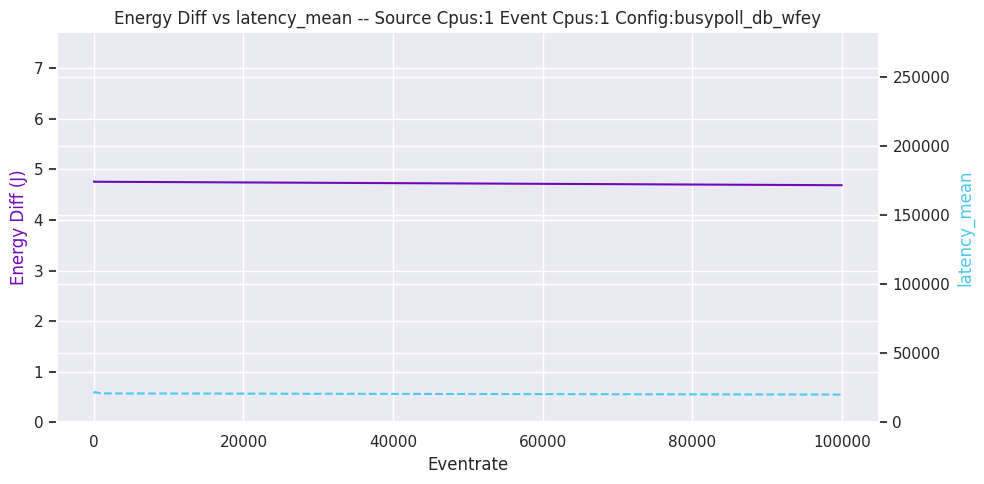

In [8]:
df_used = return_df(bm_perf_output_flat_raw)
config_set = None

num_ecpus = "1"
num_scpus = "1"
cur_config = "busypoll_db_wfey"

plt.figure()
config_set = return_config_set(df_used, num_ecpus, num_scpus, cur_config)
#print(config_set)

fig, ax1 = plt.subplots(figsize=(10, 5))

sns.lineplot(
    data=config_set, 
    x='eventrate',
    y=bm_var_energy,
    ax=ax1,
    legend=False,
    hue=ax1,
    palette=palette_y1,
    errorbar=None,
    markers=True,
)
ax2 = ax1.twinx()

sns.lineplot(
    data=config_set, 
    x='eventrate',
    y=bm_var_to_compare,
    ax=ax2,
    legend=False,
    hue=ax1,
    palette=palette_y2,
    errorbar=None,
    linestyle='--',
    markers=True
)


plt.title(bm_var_energy+' vs ' + bm_var_to_compare + ' -- Source Cpus:'+str(num_scpus) +' Event Cpus:'+str(num_ecpus) +' Config:'+str(cur_config) )
ax1.set_xlabel('Eventrate')
ax1.set_ylabel(bm_var_energy + ' (J)', color=palette_y1[0])
ax2.set_ylabel(bm_var_to_compare, color=palette_y2[0])
ax1.set_ylim(0,(df_used[bm_var_energy].max())+1) 
ax2.set_ylim(0,(df_used[bm_var_to_compare].max()))

plt.tight_layout()

##### 10 Event Source, 1 Event Processor

Event Rate subset:  [0, 10, 100, 1000, 100000]
Source CPU subset:  ['1', '10', '50']


<Figure size 640x480 with 0 Axes>

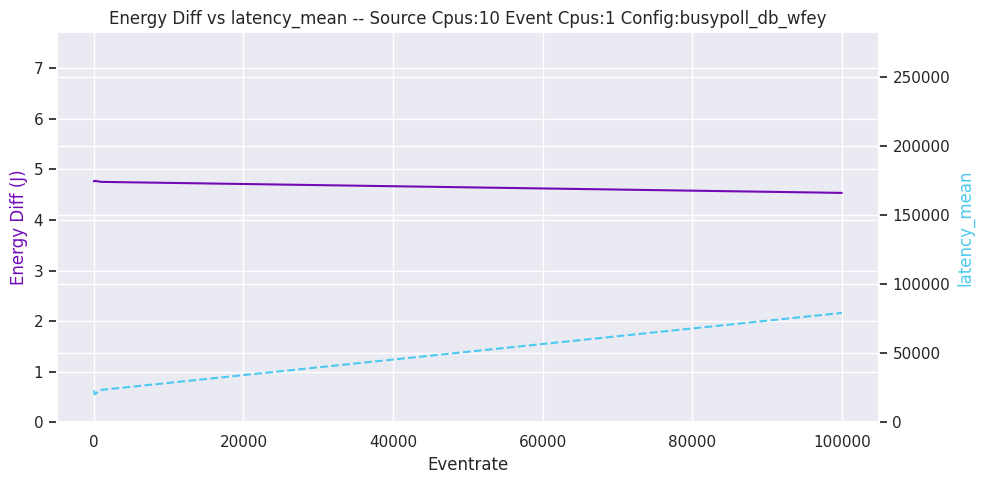

In [9]:
df_used = return_df(bm_perf_output_flat_raw)
config_set = None

num_ecpus = "1"
num_scpus = "10"
cur_config = "busypoll_db_wfey"

plt.figure()
config_set = return_config_set(df_used, num_ecpus, num_scpus, cur_config)
#print(config_set)

fig, ax1 = plt.subplots(figsize=(10, 5))

sns.lineplot(
    data=config_set, 
    x='eventrate',
    y=bm_var_energy,
    ax=ax1,
    legend=False,
    hue=ax1,
    palette=palette_y1,
    errorbar=None,
    markers=True,
)
ax2 = ax1.twinx()

sns.lineplot(
    data=config_set, 
    x='eventrate',
    y=bm_var_to_compare,
    ax=ax2,
    legend=False,
    hue=ax1,
    palette=palette_y2,
    errorbar=None,
    linestyle='--',
    markers=True
)


plt.title(bm_var_energy+' vs ' + bm_var_to_compare + ' -- Source Cpus:'+str(num_scpus) +' Event Cpus:'+str(num_ecpus) +' Config:'+str(cur_config) )
ax1.set_xlabel('Eventrate')
ax1.set_ylabel(bm_var_energy + ' (J)', color=palette_y1[0])
ax2.set_ylabel(bm_var_to_compare, color=palette_y2[0])
ax1.set_ylim(0,(df_used[bm_var_energy].max())+1) 
ax2.set_ylim(0,(df_used[bm_var_to_compare].max()))

plt.tight_layout()

##### 50 Event Source, 1 Event Processor

Event Rate subset:  [0, 10, 100, 1000, 100000]
Source CPU subset:  ['1', '10', '50']


<Figure size 640x480 with 0 Axes>

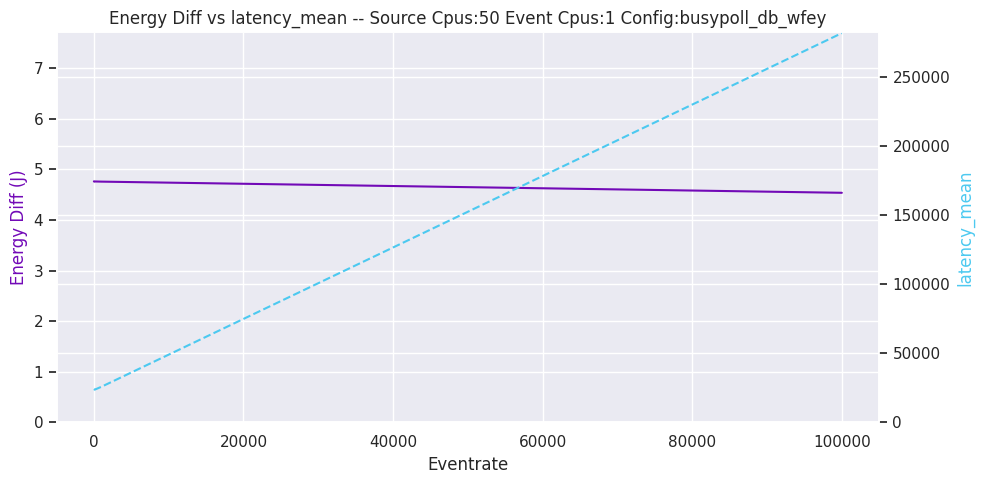

In [10]:
df_used = return_df(bm_perf_output_flat_raw)
config_set = None

num_ecpus = "1"
num_scpus = "50"
cur_config = "busypoll_db_wfey"

plt.figure()
config_set = return_config_set(df_used, num_ecpus, num_scpus, cur_config)
#print(config_set)

fig, ax1 = plt.subplots(figsize=(10, 5))

sns.lineplot(
    data=config_set, 
    x='eventrate',
    y=bm_var_energy,
    ax=ax1,
    legend=False,
    hue=ax1,
    palette=palette_y1,
    errorbar=None,
    markers=True,
)
ax2 = ax1.twinx()

sns.lineplot(
    data=config_set, 
    x='eventrate',
    y=bm_var_to_compare,
    ax=ax2,
    legend=False,
    hue=ax1,
    palette=palette_y2,
    errorbar=None,
    linestyle='--',
    markers=True
)


plt.title(bm_var_energy+' vs ' + bm_var_to_compare + ' -- Source Cpus:'+str(num_scpus) +' Event Cpus:'+str(num_ecpus) +' Config:'+str(cur_config) )
ax1.set_xlabel('Eventrate')
ax1.set_ylabel(bm_var_energy + ' (J)', color=palette_y1[0])
ax2.set_ylabel(bm_var_to_compare, color=palette_y2[0])
ax1.set_ylim(0,(df_used[bm_var_energy].max())+1) 
ax2.set_ylim(0,(df_used[bm_var_to_compare].max()))

plt.tight_layout()

### WFE WithOUT Doorbell

##### 1 Event Source, 1 Event Processor

Event Rate subset:  [0, 10, 100, 1000, 100000]
Source CPU subset:  ['1', '10', '50']


<Figure size 640x480 with 0 Axes>

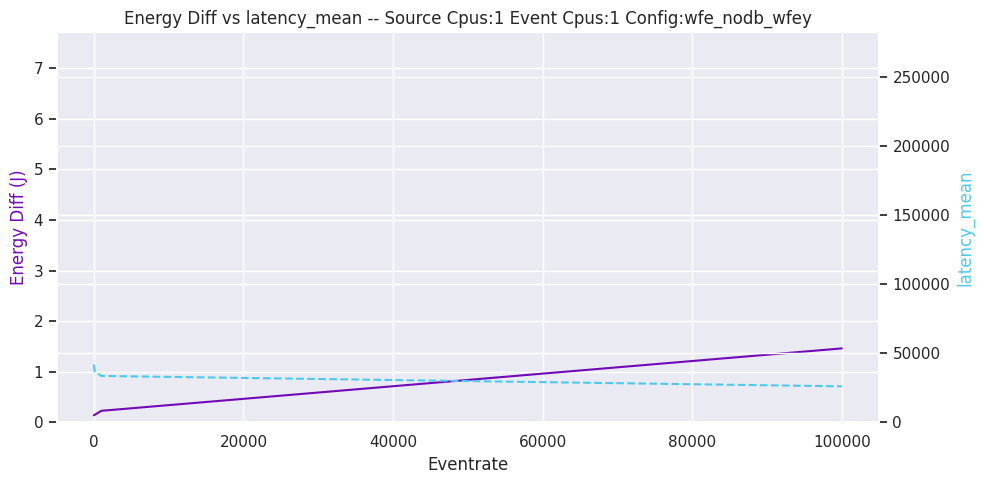

In [11]:
df_used = return_df(bm_perf_output_flat_raw)
config_set = None

num_ecpus = "1"
num_scpus = "1"
cur_config = "wfe_nodb_wfey"

plt.figure()
config_set = return_config_set(df_used, num_ecpus, num_scpus, cur_config)
#print(config_set)

fig, ax1 = plt.subplots(figsize=(10, 5))

sns.lineplot(
    data=config_set, 
    x='eventrate',
    y=bm_var_energy,
    ax=ax1,
    legend=False,
    hue=ax1,
    palette=palette_y1,
    errorbar=None,
    markers=True,
)
ax2 = ax1.twinx()

sns.lineplot(
    data=config_set, 
    x='eventrate',
    y=bm_var_to_compare,
    ax=ax2,
    legend=False,
    hue=ax1,
    palette=palette_y2,
    errorbar=None,
    linestyle='--',
    markers=True
)


plt.title(bm_var_energy+' vs ' + bm_var_to_compare + ' -- Source Cpus:'+str(num_scpus) +' Event Cpus:'+str(num_ecpus) +' Config:'+str(cur_config) )
ax1.set_xlabel('Eventrate')
ax1.set_ylabel(bm_var_energy + ' (J)', color=palette_y1[0])
ax2.set_ylabel(bm_var_to_compare, color=palette_y2[0])
ax1.set_ylim(0,(df_used[bm_var_energy].max())+1) 
ax2.set_ylim(0,(df_used[bm_var_to_compare].max()))

plt.tight_layout()

##### 10 Event Source, 1 Event Processor

Event Rate subset:  [0, 10, 100, 1000, 100000]
Source CPU subset:  ['1', '10', '50']


<Figure size 640x480 with 0 Axes>

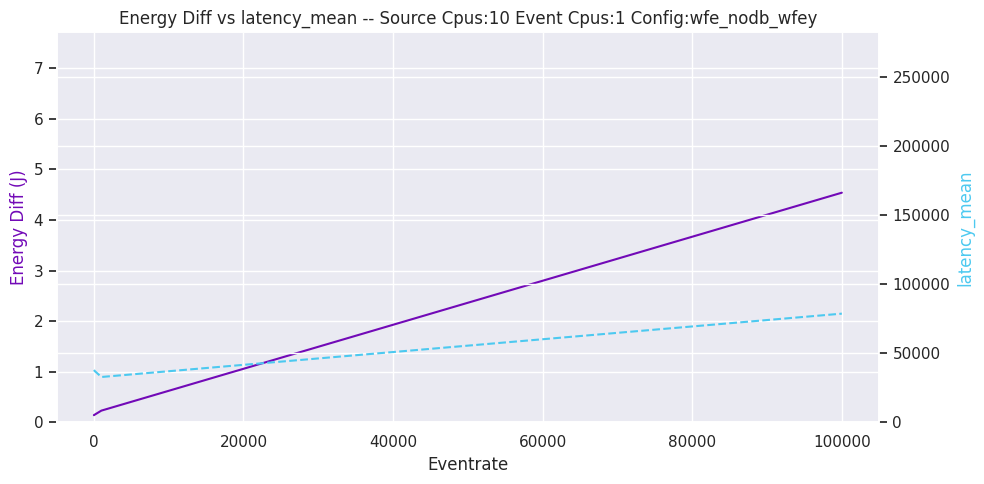

In [12]:
df_used = return_df(bm_perf_output_flat_raw)
config_set = None

num_ecpus = "1"
num_scpus = "10"
cur_config = "wfe_nodb_wfey"

plt.figure()
config_set = return_config_set(df_used, num_ecpus, num_scpus, cur_config)
#print(config_set)

fig, ax1 = plt.subplots(figsize=(10, 5))

sns.lineplot(
    data=config_set, 
    x='eventrate',
    y=bm_var_energy,
    ax=ax1,
    legend=False,
    hue=ax1,
    palette=palette_y1,
    errorbar=None,
    markers=True,
)
ax2 = ax1.twinx()

sns.lineplot(
    data=config_set, 
    x='eventrate',
    y=bm_var_to_compare,
    ax=ax2,
    legend=False,
    hue=ax1,
    palette=palette_y2,
    errorbar=None,
    linestyle='--',
    markers=True
)


plt.title(bm_var_energy+' vs ' + bm_var_to_compare + ' -- Source Cpus:'+str(num_scpus) +' Event Cpus:'+str(num_ecpus) +' Config:'+str(cur_config) )
ax1.set_xlabel('Eventrate')
ax1.set_ylabel(bm_var_energy + ' (J)', color=palette_y1[0])
ax2.set_ylabel(bm_var_to_compare, color=palette_y2[0])
ax1.set_ylim(0,(df_used[bm_var_energy].max())+1) 
ax2.set_ylim(0,(df_used[bm_var_to_compare].max()))

plt.tight_layout()

##### 50 Event Source, 1 Event Processor

Event Rate subset:  [0, 10, 100, 1000, 100000]
Source CPU subset:  ['1', '10', '50']


<Figure size 640x480 with 0 Axes>

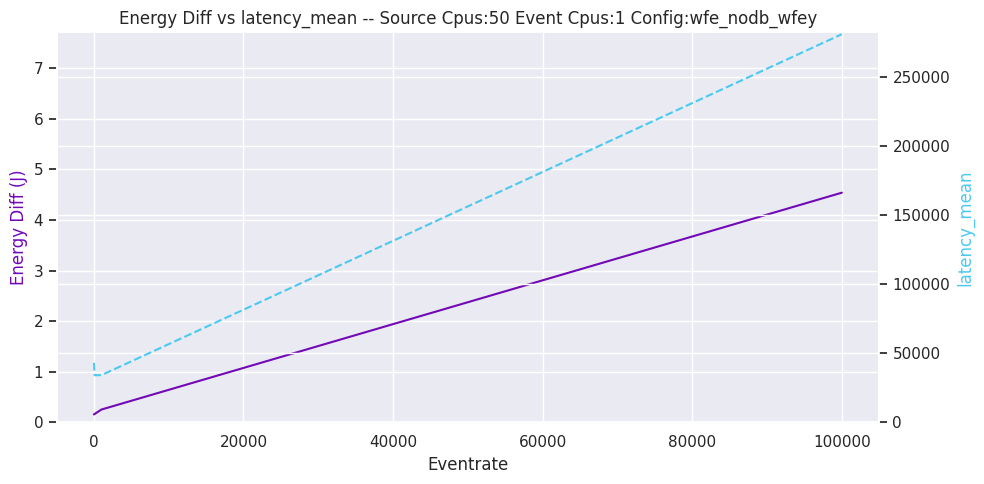

In [13]:
df_used = return_df(bm_perf_output_flat_raw)
config_set = None

num_ecpus = "1"
num_scpus = "50"
cur_config = "wfe_nodb_wfey"

plt.figure()
config_set = return_config_set(df_used, num_ecpus, num_scpus, cur_config)
#print(config_set)

fig, ax1 = plt.subplots(figsize=(10, 5))

sns.lineplot(
    data=config_set, 
    x='eventrate',
    y=bm_var_energy,
    ax=ax1,
    legend=False,
    hue=ax1,
    palette=palette_y1,
    errorbar=None,
    markers=True,
)
ax2 = ax1.twinx()

sns.lineplot(
    data=config_set, 
    x='eventrate',
    y=bm_var_to_compare,
    ax=ax2,
    legend=False,
    hue=ax1,
    palette=palette_y2,
    errorbar=None,
    linestyle='--',
    markers=True
)


plt.title(bm_var_energy+' vs ' + bm_var_to_compare + ' -- Source Cpus:'+str(num_scpus) +' Event Cpus:'+str(num_ecpus) +' Config:'+str(cur_config) )
ax1.set_xlabel('Eventrate')
ax1.set_ylabel(bm_var_energy + ' (J)', color=palette_y1[0])
ax2.set_ylabel(bm_var_to_compare, color=palette_y2[0])
ax1.set_ylim(0,(df_used[bm_var_energy].max())+1) 
ax2.set_ylim(0,(df_used[bm_var_to_compare].max()))

plt.tight_layout()

### WFE With Doorbell (No Monitor)

##### 1 Event Source, 1 Event Processor

Event Rate subset:  [0, 10, 100, 1000, 100000]
Source CPU subset:  ['1', '10', '50']


<Figure size 640x480 with 0 Axes>

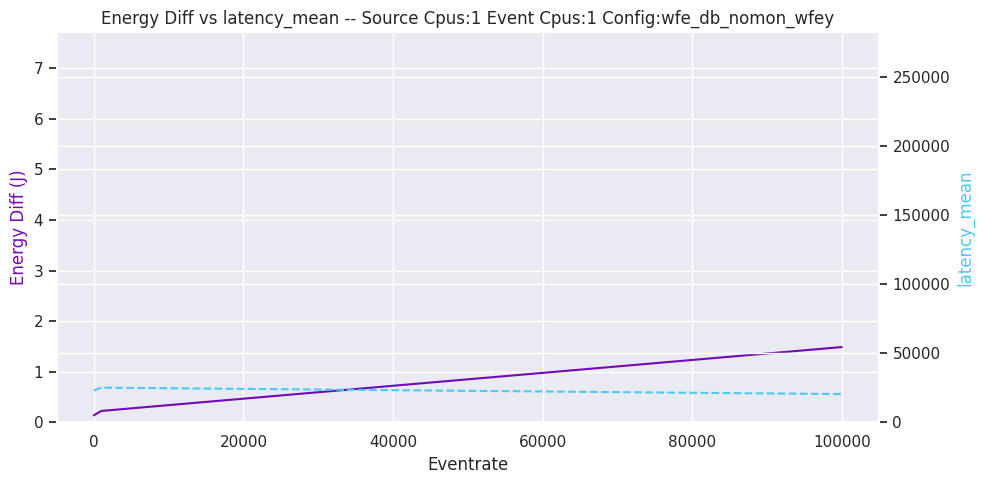

In [14]:
df_used = return_df(bm_perf_output_flat_raw)
config_set = None

num_ecpus = "1"
num_scpus = "1"
cur_config = "wfe_db_nomon_wfey"

plt.figure()
config_set = return_config_set(df_used, num_ecpus, num_scpus, cur_config)
#print(config_set)

fig, ax1 = plt.subplots(figsize=(10, 5))

sns.lineplot(
    data=config_set, 
    x='eventrate',
    y=bm_var_energy,
    ax=ax1,
    legend=False,
    hue=ax1,
    palette=palette_y1,
    errorbar=None,
    markers=True,
)
ax2 = ax1.twinx()

sns.lineplot(
    data=config_set, 
    x='eventrate',
    y=bm_var_to_compare,
    ax=ax2,
    legend=False,
    hue=ax1,
    palette=palette_y2,
    errorbar=None,
    linestyle='--',
    markers=True
)


plt.title(bm_var_energy+' vs ' + bm_var_to_compare + ' -- Source Cpus:'+str(num_scpus) +' Event Cpus:'+str(num_ecpus) +' Config:'+str(cur_config) )
ax1.set_xlabel('Eventrate')
ax1.set_ylabel(bm_var_energy + ' (J)', color=palette_y1[0])
ax2.set_ylabel(bm_var_to_compare, color=palette_y2[0])
ax1.set_ylim(0,(df_used[bm_var_energy].max())+1) 
ax2.set_ylim(0,(df_used[bm_var_to_compare].max()))

plt.tight_layout()

##### 10 Event Source, 1 Event Processor

Event Rate subset:  [0, 10, 100, 1000, 100000]
Source CPU subset:  ['1', '10', '50']


<Figure size 640x480 with 0 Axes>

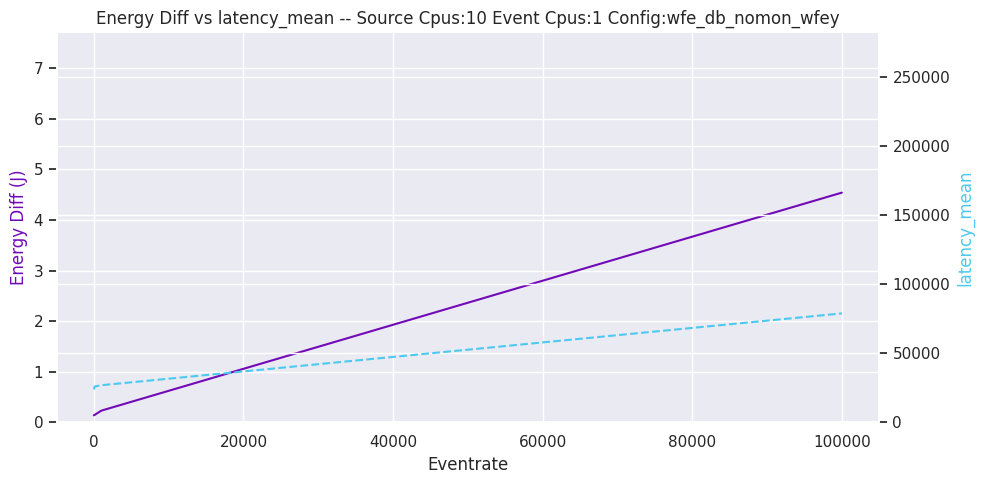

In [15]:
df_used = return_df(bm_perf_output_flat_raw)
config_set = None

num_ecpus = "1"
num_scpus = "10"
cur_config = "wfe_db_nomon_wfey"

plt.figure()
config_set = return_config_set(df_used, num_ecpus, num_scpus, cur_config)
#print(config_set)

fig, ax1 = plt.subplots(figsize=(10, 5))

sns.lineplot(
    data=config_set, 
    x='eventrate',
    y=bm_var_energy,
    ax=ax1,
    legend=False,
    hue=ax1,
    palette=palette_y1,
    errorbar=None,
    markers=True,
)
ax2 = ax1.twinx()

sns.lineplot(
    data=config_set, 
    x='eventrate',
    y=bm_var_to_compare,
    ax=ax2,
    legend=False,
    hue=ax1,
    palette=palette_y2,
    errorbar=None,
    linestyle='--',
    markers=True
)


plt.title(bm_var_energy+' vs ' + bm_var_to_compare + ' -- Source Cpus:'+str(num_scpus) +' Event Cpus:'+str(num_ecpus) +' Config:'+str(cur_config) )
ax1.set_xlabel('Eventrate')
ax1.set_ylabel(bm_var_energy + ' (J)', color=palette_y1[0])
ax2.set_ylabel(bm_var_to_compare, color=palette_y2[0])
ax1.set_ylim(0,(df_used[bm_var_energy].max())+1) 
ax2.set_ylim(0,(df_used[bm_var_to_compare].max()))

plt.tight_layout()

##### 50 Event Source, 1 Event Processor

Event Rate subset:  [0, 10, 100, 1000, 100000]
Source CPU subset:  ['1', '10', '50']


<Figure size 640x480 with 0 Axes>

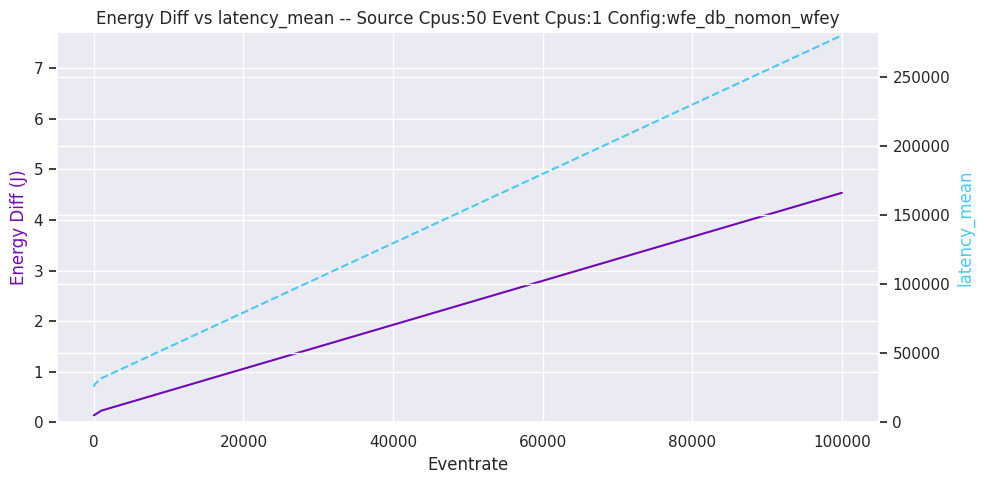

In [16]:
df_used = return_df(bm_perf_output_flat_raw)
config_set = None

num_ecpus = "1"
num_scpus = "50"
cur_config = "wfe_db_nomon_wfey"

plt.figure()
config_set = return_config_set(df_used, num_ecpus, num_scpus, cur_config)
#print(config_set)

fig, ax1 = plt.subplots(figsize=(10, 5))

sns.lineplot(
    data=config_set, 
    x='eventrate',
    y=bm_var_energy,
    ax=ax1,
    legend=False,
    hue=ax1,
    palette=palette_y1,
    errorbar=None,
    markers=True,
)
ax2 = ax1.twinx()

sns.lineplot(
    data=config_set, 
    x='eventrate',
    y=bm_var_to_compare,
    ax=ax2,
    legend=False,
    hue=ax1,
    palette=palette_y2,
    errorbar=None,
    linestyle='--',
    markers=True
)


plt.title(bm_var_energy+' vs ' + bm_var_to_compare + ' -- Source Cpus:'+str(num_scpus) +' Event Cpus:'+str(num_ecpus) +' Config:'+str(cur_config) )
ax1.set_xlabel('Eventrate')
ax1.set_ylabel(bm_var_energy + ' (J)', color=palette_y1[0])
ax2.set_ylabel(bm_var_to_compare, color=palette_y2[0])
ax1.set_ylim(0,(df_used[bm_var_energy].max())+1) 
ax2.set_ylim(0,(df_used[bm_var_to_compare].max()))

plt.tight_layout()

### WFE With Doorbell (With Monitor)

##### 1 Event Source, 1 Event Processor

Event Rate subset:  [0, 10, 100, 1000, 100000]
Source CPU subset:  ['1', '10', '50']


<Figure size 640x480 with 0 Axes>

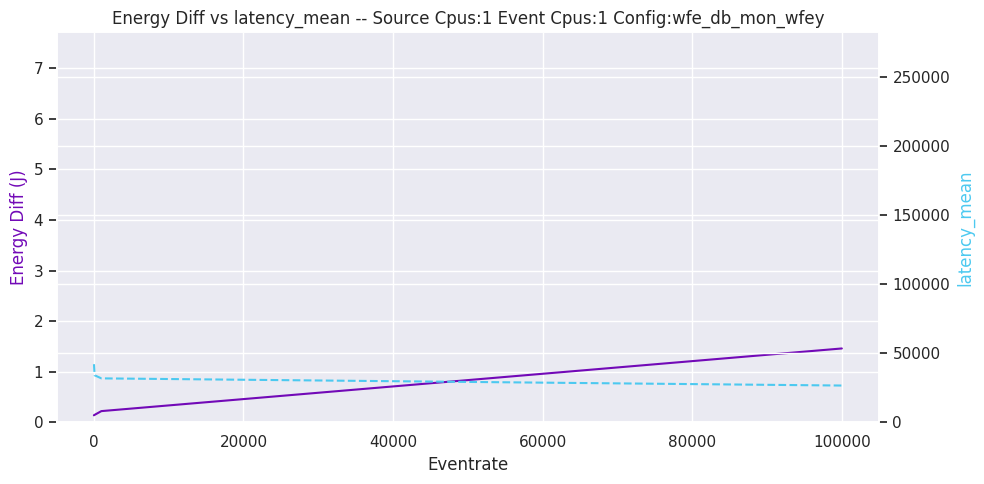

In [17]:
df_used = return_df(bm_perf_output_flat_raw)
config_set = None

num_ecpus = "1"
num_scpus = "1"
cur_config = "wfe_db_mon_wfey"

plt.figure()
config_set = return_config_set(df_used, num_ecpus, num_scpus, cur_config)
#print(config_set)

fig, ax1 = plt.subplots(figsize=(10, 5))

sns.lineplot(
    data=config_set, 
    x='eventrate',
    y=bm_var_energy,
    ax=ax1,
    legend=False,
    hue=ax1,
    palette=palette_y1,
    errorbar=None,
    markers=True,
)
ax2 = ax1.twinx()

sns.lineplot(
    data=config_set, 
    x='eventrate',
    y=bm_var_to_compare,
    ax=ax2,
    legend=False,
    hue=ax1,
    palette=palette_y2,
    errorbar=None,
    linestyle='--',
    markers=True
)


plt.title(bm_var_energy+' vs ' + bm_var_to_compare + ' -- Source Cpus:'+str(num_scpus) +' Event Cpus:'+str(num_ecpus) +' Config:'+str(cur_config) )
ax1.set_xlabel('Eventrate')
ax1.set_ylabel(bm_var_energy + ' (J)', color=palette_y1[0])
ax2.set_ylabel(bm_var_to_compare, color=palette_y2[0])
ax1.set_ylim(0,(df_used[bm_var_energy].max())+1) 
ax2.set_ylim(0,(df_used[bm_var_to_compare].max()))

plt.tight_layout()

##### 10 Event Source, 1 Event Processor

Event Rate subset:  [0, 10, 100, 1000, 100000]
Source CPU subset:  ['1', '10', '50']


<Figure size 640x480 with 0 Axes>

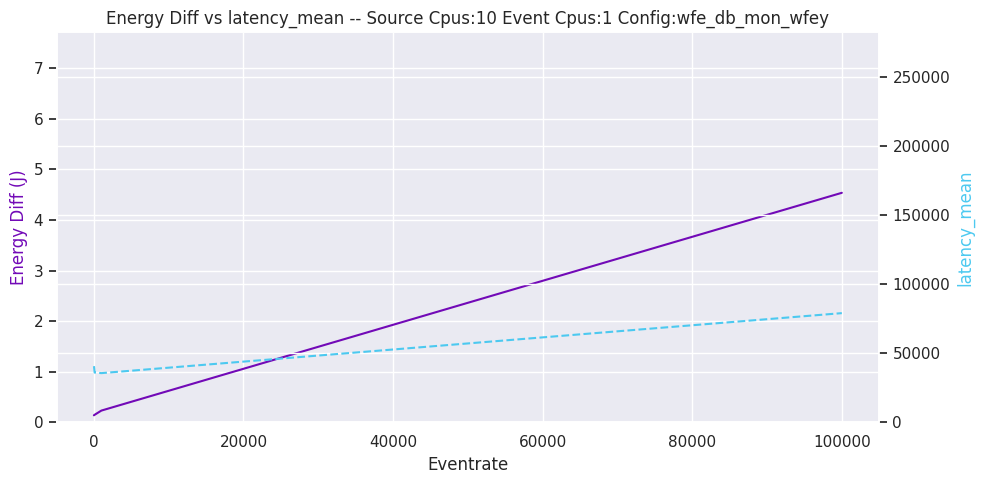

In [18]:
df_used = return_df(bm_perf_output_flat_raw)
config_set = None

num_ecpus = "1"
num_scpus = "10"
cur_config = "wfe_db_mon_wfey"

plt.figure()
config_set = return_config_set(df_used, num_ecpus, num_scpus, cur_config)
#print(config_set)

fig, ax1 = plt.subplots(figsize=(10, 5))

sns.lineplot(
    data=config_set, 
    x='eventrate',
    y=bm_var_energy,
    ax=ax1,
    legend=False,
    hue=ax1,
    palette=palette_y1,
    errorbar=None,
    markers=True,
)
ax2 = ax1.twinx()

sns.lineplot(
    data=config_set, 
    x='eventrate',
    y=bm_var_to_compare,
    ax=ax2,
    legend=False,
    hue=ax1,
    palette=palette_y2,
    errorbar=None,
    linestyle='--',
    markers=True
)


plt.title(bm_var_energy+' vs ' + bm_var_to_compare + ' -- Source Cpus:'+str(num_scpus) +' Event Cpus:'+str(num_ecpus) +' Config:'+str(cur_config) )
ax1.set_xlabel('Eventrate')
ax1.set_ylabel(bm_var_energy + ' (J)', color=palette_y1[0])
ax2.set_ylabel(bm_var_to_compare, color=palette_y2[0])
ax1.set_ylim(0,(df_used[bm_var_energy].max())+1) 
ax2.set_ylim(0,(df_used[bm_var_to_compare].max()))

plt.tight_layout()

##### 50 Event Source, 1 Event Processor

Event Rate subset:  [0, 10, 100, 1000, 100000]
Source CPU subset:  ['1', '10', '50']


<Figure size 640x480 with 0 Axes>

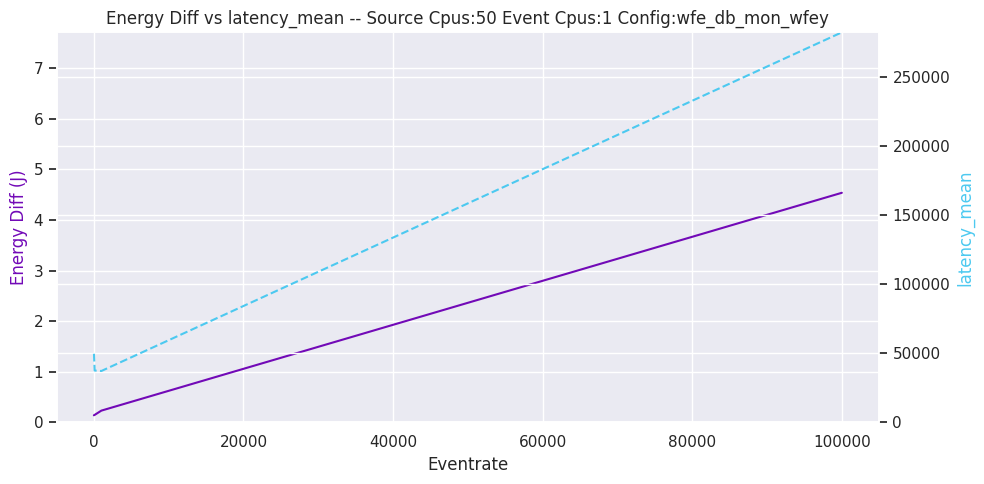

In [19]:
df_used = return_df(bm_perf_output_flat_raw)
config_set = None

num_ecpus = "1"
num_scpus = "50"
cur_config = "wfe_db_mon_wfey"

plt.figure()
config_set = return_config_set(df_used, num_ecpus, num_scpus, cur_config)
#print(config_set)

fig, ax1 = plt.subplots(figsize=(10, 5))

sns.lineplot(
    data=config_set, 
    x='eventrate',
    y=bm_var_energy,
    ax=ax1,
    legend=False,
    hue=ax1,
    palette=palette_y1,
    errorbar=None,
    markers=True,
)
ax2 = ax1.twinx()

sns.lineplot(
    data=config_set, 
    x='eventrate',
    y=bm_var_to_compare,
    ax=ax2,
    legend=False,
    hue=ax1,
    palette=palette_y2,
    errorbar=None,
    linestyle='--',
    markers=True
)


plt.title(bm_var_energy+' vs ' + bm_var_to_compare + ' -- Source Cpus:'+str(num_scpus) +' Event Cpus:'+str(num_ecpus) +' Config:'+str(cur_config) )
ax1.set_xlabel('Eventrate')
ax1.set_ylabel(bm_var_energy + ' (J)', color=palette_y1[0])
ax2.set_ylabel(bm_var_to_compare, color=palette_y2[0])
ax1.set_ylim(0,(df_used[bm_var_energy].max())+1) 
ax2.set_ylim(0,(df_used[bm_var_to_compare].max()))

plt.tight_layout()